In [3]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd 

In [4]:
diabetes = load_diabetes()
X,y = diabetes.data, diabetes.target

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
def create_model(lr):
    m=Sequential([Dense(16,activation='relu' ,input_shape=(10,)),
                  Dense(8,activation='relu'),
                  Dense(1,activation='linear')])
    m.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae']
    )
    return m

In [20]:
learning_rates = [0.1, 0.01, 0.001]
results = []

for lr in learning_rates:
    model = create_model(lr)

    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=16,
        verbose=0
    )

    loss, mae = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([lr, loss])

df = pd.DataFrame(results, columns=["Learning Rate", "Mean Squared Error"])

print(df)

   Learning Rate  Mean Squared Error
0          0.100        26222.748047
1          0.010        26172.376953
2          0.001        25930.019531


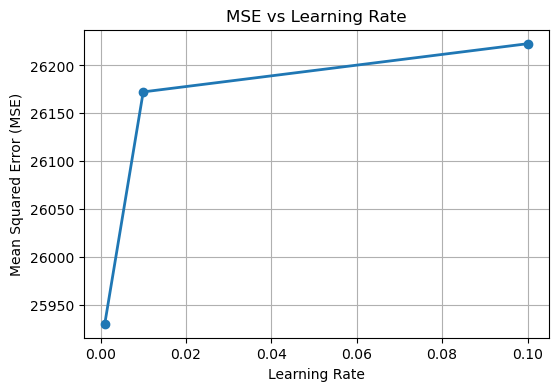

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    df["Learning Rate"],
    df["Mean Squared Error"],
    marker='o',
    linewidth=2
)

plt.xlabel("Learning Rate")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs Learning Rate")
plt.grid(True)

plt.show()

In [25]:
epochs_list = [5, 10, 20]
res = []

for ep in epochs_list:
    model = create_model(0.001)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, mae = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    res.append([ep, loss, mae])

edf = pd.DataFrame(
    res,
    columns=["Epochs", "MSE", "MAE"]
)

print(edf)

   Epochs           MSE         MAE
0       5  26520.267578  145.684509
1      10  26500.806641  145.612869
2      20  26377.652344  145.194672


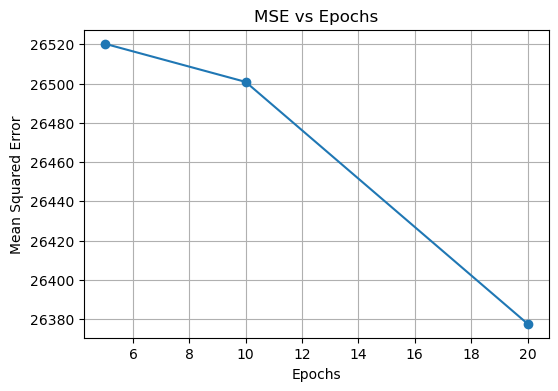

In [26]:
plt.figure(figsize=(6,4))

plt.plot(
    edf["Epochs"],
    edf["MSE"],
    marker="o"
)

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Epochs")
plt.grid(True)

plt.show()

In [28]:
model = create_model(0.001)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 31528.9707 - mae: 158.6752 - val_loss: 22487.3477 - val_mae: 134.0986
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 31524.7441 - mae: 158.6617 - val_loss: 22483.8203 - val_mae: 134.0854
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 31520.6055 - mae: 158.6483 - val_loss: 22480.2285 - val_mae: 134.0720
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 31516.4043 - mae: 158.6349 - val_loss: 22476.6250 - val_mae: 134.0587
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 31512.1309 - mae: 158.6213 - val_loss: 22472.9512 - val_mae: 134.0450
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 31507.7520 - mae: 158.6074 - val_loss: 22469.1543 - val_mae: 134.0310
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 31503.2012 - mae: 158.5933 - val_loss: 22465.2910 - val_mae: 134.0166
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 31498.5527 - mae: 158.5786 - val_loss: 22461.2461 - va

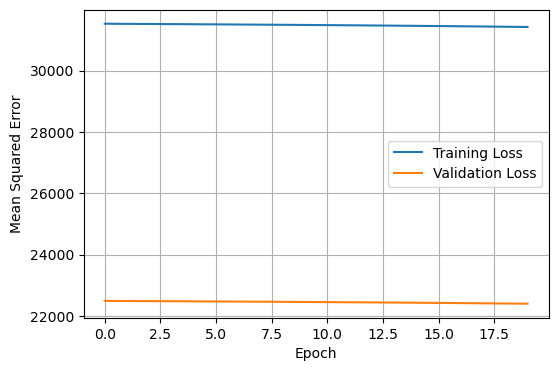

In [29]:
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.legend(["Training Loss", "Validation Loss"])

plt.grid(True)

plt.show()

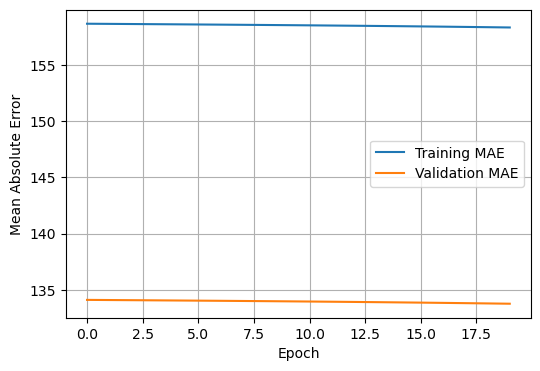

In [30]:
plt.figure(figsize=(6,4))

plt.plot(history.history["mae"])
plt.plot(history.history["val_mae"])

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")

plt.legend(["Training MAE", "Validation MAE"])

plt.grid(True)

plt.show()

In [32]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print(f"Test MSE : {loss:.2f}")
print(f"Test MAE : {mae:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 26447.5977 - mae: 145.4267
Test MSE : 26447.60
Test MAE : 145.43
